# 02 · Demanda y operación

**Objetivo:** identificar en qué zonas, días y horas se concentra la demanda y cuánto ingreso genera cada hora de servicio, como insumo para ubicar la flota.

**Insumo:** la base procesada (`data/processed/viajes_marcados.parquet`), construida con `uv run nyc-taxi-ops procesar`.

**Definiciones**

- **Ingreso del servicio:** tarifa + recargos + propina. Excluye peajes, el impuesto MTA y el recargo de mejora, que se trasladan a terceros. Las propinas en efectivo no quedan registradas.
- **Ingreso por hora de servicio:** ingreso dividido por las horas con pasajero a bordo, solo en viajes con duración y velocidad plausibles.
- **Velocidad media:** millas totales / horas totales.
- **Promedios por día:** el mes tiene 20 días laborables y 11 de fin de semana o festivo (1, 2 y 16 de enero incluidos).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nyc_taxi_ops import agregados, auditoria, calidad, config, datos, graficos, imputacion, pipeline

graficos.estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
base = pipeline.cargar_base(['fecha', 'hora', 'dia_semana', 'tipo_dia', 'franja', 'PULocationID', 'DOLocationID', 'pu_distrito', 'ingreso', 'valido_demanda', 'valido_ingreso', 'valido_tiempo', 'duracion_min', 'distancia_final', 'fare_amount', 'tip_amount', 'payment_type'])
b = agregados.preparar_demanda(base)
dias = b.groupby("tipo_dia", observed=True)["fecha"].nunique()
print(f"Viajes en la base analítica: {len(b):,}")
dias

Viajes en la base analítica: 9,673,906


tipo_dia
Laborable                20
Fin de semana/festivo    11
Name: fecha, dtype: int64

## 1. Indicadores generales

In [3]:
pd.Series(agregados.tabla_kpis(base)).to_frame("valor")

,valor
viajes_originales,"9,710,820.00"
viajes_base,"9,673,906.00"
ingreso,"138,910,224.29"
ingreso_por_viaje,14.36
duracion_mediana_min,10.37
velocidad_mph,12.97
ingreso_por_hora,65.28
pct_tarjeta,67.21
propina_pct_tarjeta,20.49


## 2. ¿Cuándo? Día de la semana × hora

Promedio de viajes por día para cada combinación de día de la semana y hora de recogida. Se excluyen los festivos (2 y 16 de enero, ambos lunes) para que no arrastren el promedio de los lunes.

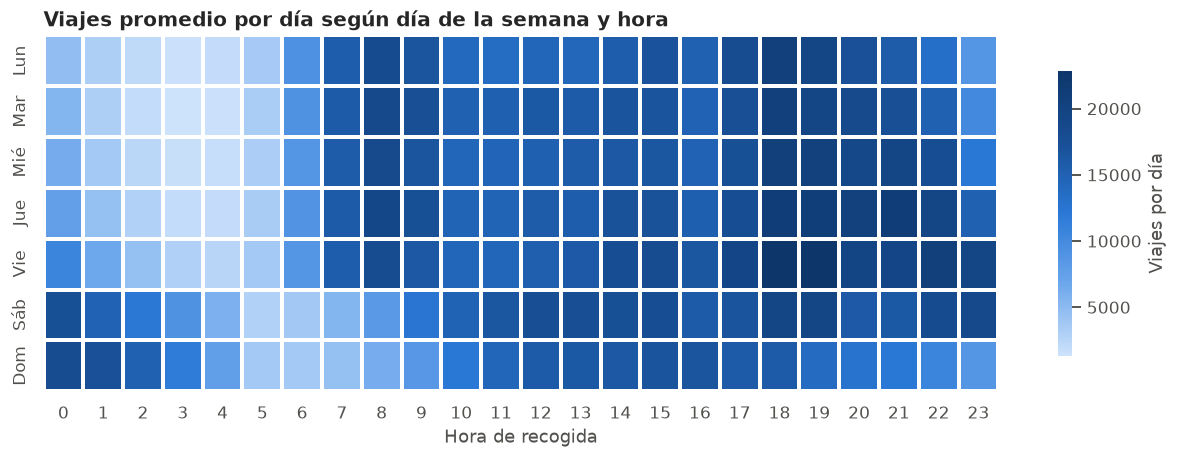

In [4]:
festivos = pd.to_datetime(list(config.FESTIVOS))
sin_festivos = b.loc[~b["fecha"].isin(festivos)]
n_dias = sin_festivos.groupby("dia_semana")["fecha"].nunique()
matriz = sin_festivos.groupby(["dia_semana", "hora"]).size().unstack().div(n_dias, axis=0)
matriz.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

fig, ax = plt.subplots(figsize=(14, 4.2))
sns.heatmap(matriz, cmap=graficos.SECUENCIAL, linewidths=1.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Viajes por día", "shrink": 0.8})
ax.set_xlabel("Hora de recogida")
ax.set_ylabel("")
ax.set_title("Viajes promedio por día según día de la semana y hora")
graficos.guardar(fig, "02_heatmap_demanda.png")
plt.show()

### Lectura

De entrada, el mapa de calor permite identificar que la demanda no se distribuye de manera uniforme a lo largo de la semana, ya que entre la hora de menor y la de mayor actividad hay una diferencia de aproximadamente 17 veces, pasando de 1,345 viajes promedio a las 3:00 de los martes a 22,840 a las 19:00 de los viernes. Por un lado, en los días laborables se observan dos picos bien definidos, uno en la mañana alrededor de las 8:00 (18,583 viajes en promedio) y otro más intenso al final de la tarde entre las 18:00 y las 19:00 (20,937), los cuales coinciden con los horarios de entrada y salida laboral. Por otro lado, los fines de semana presentan un comportamiento distinto, donde la franja entre las 0:00 y las 2:00 alcanza en promedio 15,814 viajes por hora, frente a 4,650 en los días laborables, lo que es coherente con desplazamientos asociados al ocio nocturno, patrón que ya se había sugerido en las reglas de asociación del proyecto del curso (Grupo + Madrugada → Fin de semana).

Teniendo en cuenta lo anterior, para la operación de una flota esto implica que la disponibilidad de vehículos debería ajustarse a dos calendarios distintos: en los días laborables, a los picos de entrada y salida, y en los fines de semana, a la noche y la madrugada, en lugar de mantener una oferta constante durante todo el día.

## 3. Día a día

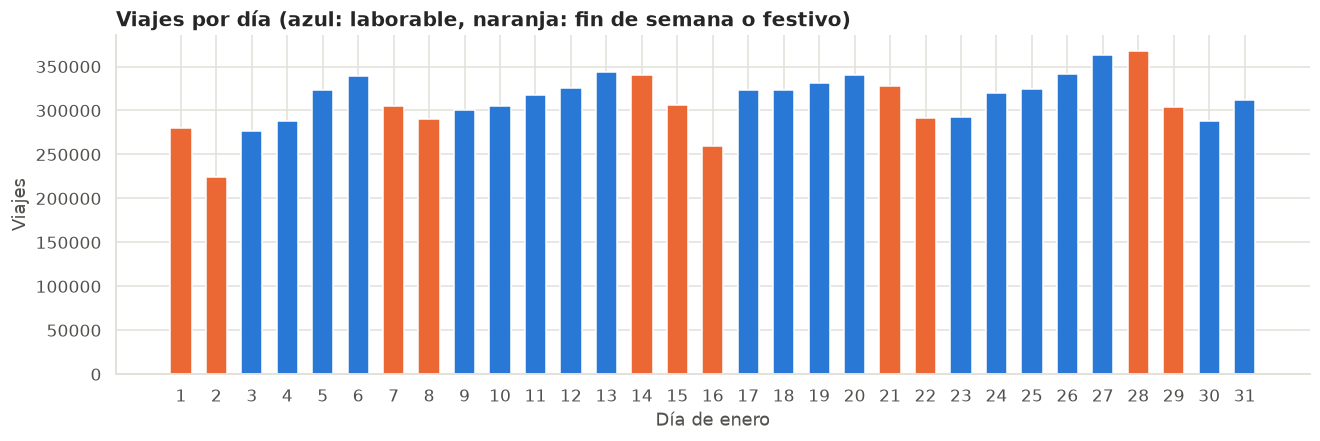

,fecha,tipo_dia,viajes
1,2017-01-02,Fin de semana/festivo,223998
15,2017-01-16,Fin de semana/festivo,259263
2,2017-01-03,Laborable,277051
0,2017-01-01,Fin de semana/festivo,279969
29,2017-01-30,Laborable,288100


In [5]:
diario = b.groupby(["fecha", "tipo_dia"], observed=True).size().reset_index(name="viajes")
colores = diario["tipo_dia"].map({"Laborable": graficos.AZUL, "Fin de semana/festivo": graficos.NARANJA})
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(diario["fecha"].dt.day, diario["viajes"], color=colores, width=0.6)
ax.set_xticks(range(1, 32))
ax.set_xlabel("Día de enero")
ax.set_ylabel("Viajes")
ax.set_title("Viajes por día (azul: laborable, naranja: fin de semana o festivo)")
plt.show()
diario.sort_values("viajes").head(5)

### Lectura

En lo que concierne al comportamiento día a día, los dos días con menor número de viajes corresponden a los festivos, el lunes 2 de enero (223,998 viajes) y el lunes 16 de enero (259,263), ambos por debajo del promedio del mes de 312,061 viajes diarios, lo que respalda la decisión de tratarlos como días no laborables. Así mismo, al comparar los días de la semana sin festivos, la demanda aumenta progresivamente de lunes (293,890 viajes en promedio) a viernes (346,476), se mantiene alta el sábado (335,105) y cae el domingo (294,267), siendo el viernes y el sábado los días de mayor actividad. Finalmente, el día con más viajes del mes fue el sábado 28 de enero, con 367,082.

## 4. Productividad por hora

El volumen no es lo único que importa para ubicar la flota: una hora con muchos viajes lentos puede generar menos ingreso por hora ocupada que una hora con menos viajes pero más rápidos.

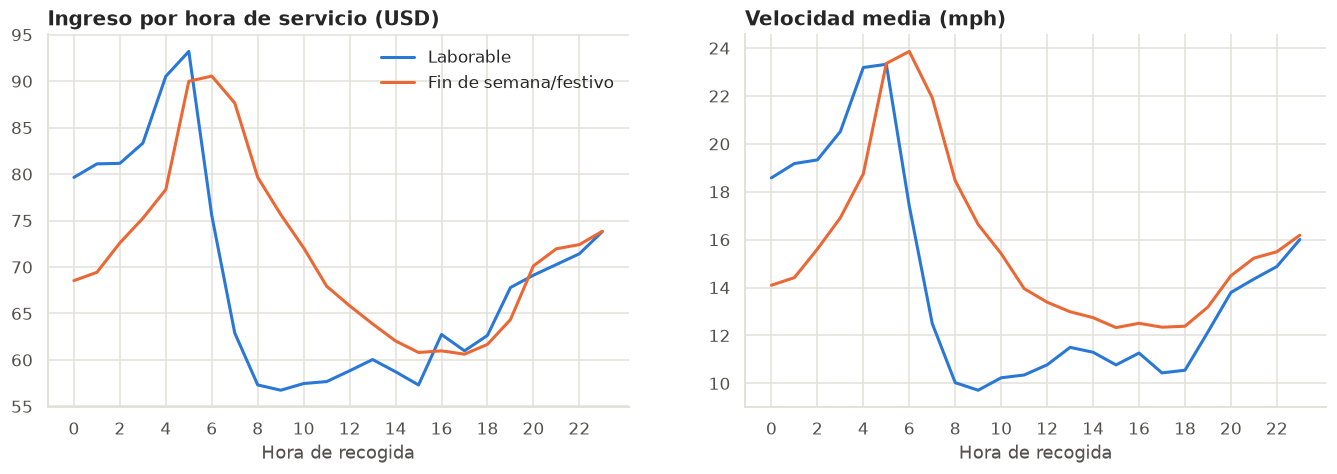

In [6]:
tiempo = b["valido_tiempo"]
por_hora = (
    b.loc[tiempo]
    .groupby(["tipo_dia", "hora"], observed=True)
    .agg(ingreso=("ingreso_t", "sum"), horas=("horas_t", "sum"), millas=("millas_t", "sum"))
)
por_hora["ingreso_por_hora"] = por_hora["ingreso"] / por_hora["horas"]
por_hora["velocidad"] = por_hora["millas"] / por_hora["horas"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
for tipo, color in (("Laborable", graficos.AZUL), ("Fin de semana/festivo", graficos.NARANJA)):
    sub = por_hora.loc[tipo]
    axes[0].plot(sub.index, sub["ingreso_por_hora"], color=color, lw=2, label=tipo)
    axes[1].plot(sub.index, sub["velocidad"], color=color, lw=2, label=tipo)
axes[0].set_title("Ingreso por hora de servicio (USD)")
axes[1].set_title("Velocidad media (mph)")
for ax in axes:
    ax.set_xlabel("Hora de recogida")
    ax.set_xticks(range(0, 24, 2))
axes[0].legend()
graficos.guardar(fig, "02_productividad_hora.png")
plt.show()

In [7]:
correlacion = por_hora[["ingreso_por_hora", "velocidad"]].corr().iloc[0, 1]
print(f"Correlación entre velocidad e ingreso por hora (48 combinaciones tipo de día × hora): {correlacion:.2f}")

Correlación entre velocidad e ingreso por hora (48 combinaciones tipo de día × hora): 0.99


### Lectura

Con respecto a la productividad, los resultados muestran que el ingreso por hora de servicio no sigue el mismo patrón que la demanda, sino que se comporta prácticamente como un reflejo de la velocidad, con una correlación de 0.99 entre ambas variables. De esta forma, en los días laborables el ingreso por hora ocupada alcanza su máximo a las 5:00 ($93.2), cuando la velocidad media es de 23.3 mph, y cae a su mínimo entre las 9:00 y las 15:00 (alrededor de $57), cuando la velocidad se reduce a cerca de 10 mph. Esto se explica por el funcionamiento del taxímetro, ya que cuando el vehículo circula por debajo de 12 mph el cobro pasa a hacerse por tiempo y no por distancia (NYC Taxi & Limousine Commission, s. f.), por lo que una hora con tráfico genera menos ingreso que una hora de circulación fluida.

Teniendo esto en cuenta, se hace evidente una tensión operativa: las horas con más demanda no son las más productivas por hora ocupada, lo que sugiere que para una flota no basta con ubicar vehículos donde hay más viajes, sino que también es relevante considerar la velocidad a la que esos viajes se pueden completar. Cabe señalar que este indicador mide únicamente el tiempo con pasajero a bordo, por lo que no incluye el tiempo en que el vehículo circula vacío buscando un nuevo viaje, que en las horas de mayor demanda probablemente es menor; sin embargo, esta variable no está disponible en el Dataset, por lo que ese efecto no pudo cuantificarse.

## 5. ¿Dónde? Zonas de recogida

Se muestran dos rankings: por volumen y por ingreso por hora de servicio. En el segundo se exige un mínimo de 20 viajes por día para no premiar zonas con muy pocos viajes.

In [8]:
n_total = b["fecha"].nunique()
por_zona = b.groupby("PULocationID").agg(
    viajes=("ingreso", "size"), ingreso=("ingreso", "sum"),
    ingreso_t=("ingreso_t", "sum"), horas=("horas_t", "sum"), millas=("millas_t", "sum"),
)
por_zona["viajes_dia"] = por_zona["viajes"] / n_total
por_zona["ingreso_por_hora"] = por_zona["ingreso_t"] / por_zona["horas"]
por_zona["velocidad"] = por_zona["millas"] / por_zona["horas"]
catalogo = datos.cargar_zonas().set_index("LocationID")[["zona", "distrito"]]
por_zona = por_zona.join(catalogo)
columnas = ["zona", "distrito", "viajes_dia", "ingreso_por_hora", "velocidad"]

top_volumen = por_zona.nlargest(15, "viajes_dia")[columnas]
top_productividad = por_zona.query("viajes_dia >= 20").nlargest(15, "ingreso_por_hora")[columnas]
print(f"Las 15 zonas con más viajes concentran el {top_volumen['viajes_dia'].sum() / por_zona['viajes_dia'].sum():.1%} de la demanda")
top_volumen

Las 15 zonas con más viajes concentran el 47.4% de la demanda


,zona,distrito,viajes_dia,ingreso_por_hora,velocidad
PULocationID,,,,,
237,Upper East Side South,Manhattan,"12,250.29",62.25,10.21
236,Upper East Side North,Manhattan,"11,704.55",62.40,10.53
161,Midtown Center,Manhattan,"11,616.29",61.98,11.00
186,Penn Station/Madison Sq West,Manhattan,"10,937.71",57.77,9.86
230,Times Sq/Theatre District,Manhattan,"10,744.45",63.34,12.18
234,Union Sq,Manhattan,"10,715.71",60.68,10.11
162,Midtown East,Manhattan,"10,648.39",62.67,11.17
170,Murray Hill,Manhattan,"9,851.87",62.75,10.89
79,East Village,Manhattan,"9,764.39",63.35,11.65


In [9]:
top_productividad

,zona,distrito,viajes_dia,ingreso_por_hora,velocidad
PULocationID,,,,,
1,Newark Airport,Newark (EWR),20.65,194.67,20.52
265,Fuera de NYC,Fuera de NYC,135.19,170.42,21.65
93,Flushing Meadows-Corona Park,Queens,35.42,118.79,21.76
28,Briarwood/Jamaica Hills,Queens,20.19,106.73,23.93
70,East Elmhurst,Queens,43.97,98.55,22.50
130,Jamaica,Queens,22.55,95.46,21.72
10,Baisley Park,Queens,46.13,93.65,23.74
132,JFK Airport,Queens,"7,247.29",85.61,26.33
196,Rego Park,Queens,25.42,83.23,18.21


### Lectura

En cuanto a la distribución geográfica, la demanda se encuentra altamente concentrada, ya que Manhattan reúne el 91.3% de las recogidas y las 15 zonas con más viajes, todas ubicadas en este distrito, concentran el 47.4% del total, encabezadas por Upper East Side South (12,250 viajes por día) y Upper East Side North (11,705). Sin embargo, al ordenar las zonas por ingreso por hora de servicio el ranking cambia por completo, ya que los primeros lugares los ocupan los aeropuertos y varias zonas de Queens, como Newark Airport ($194.67), Flushing Meadows-Corona Park ($118.79) y JFK Airport ($85.61), frente a valores cercanos a $62 en las zonas de mayor demanda de Manhattan.

A partir de lo anterior, se evidencia que las zonas de mayor volumen no son las de mayor productividad, dado que desde las zonas periféricas los viajes circulan a velocidades que en su mayoría superan las 20 mph, frente a velocidades de entre 10 y 12 mph en las zonas más demandadas. Esto le plantea a la operación una decisión entre dos estrategias: priorizar el volumen de Manhattan, con viajes cortos y frecuentes, o priorizar los trayectos desde aeropuertos y zonas periféricas, con mayor ingreso por hora ocupada pero con una menor cantidad de viajes.

## 6. Aeropuertos

In [10]:
filas = []
for zona_id, nombre in config.AEROPUERTOS.items():
    for sentido, columna in (("Desde", "PULocationID"), ("Hacia", "DOLocationID")):
        sub = b.loc[b[columna] == zona_id]
        filas.append({
            "aeropuerto": nombre, "sentido": sentido, "viajes_dia": len(sub) / n_total,
            "ingreso_por_viaje": sub["ingreso"].mean(),
            "ingreso_por_hora": sub["ingreso_t"].sum() / sub["horas_t"].sum(),
            "pct_ingreso_total": sub["ingreso"].sum() / b["ingreso"].sum() * 100,
        })
pd.DataFrame(filas).sort_values("viajes_dia", ascending=False)

,aeropuerto,sentido,viajes_dia,ingreso_por_viaje,ingreso_por_hora,pct_ingreso_total
0,JFK,Desde,"7,247.29",52.83,85.61,8.54
2,LaGuardia,Desde,"6,823.84",37.96,76.11,5.78
3,LaGuardia,Hacia,"3,054.39",37.93,79.39,2.59
1,JFK,Hacia,"2,255.16",56.42,82.16,2.84
5,Newark,Hacia,508.81,80.86,128.00,0.92
4,Newark,Desde,20.65,87.77,194.67,0.04


### Lectura

Finalmente, los aeropuertos representan apenas el 6.2% de los viajes, pero generan el 20.3% del ingreso del servicio, lo que los convierte en el segmento de mayor valor por viaje, con un ingreso promedio de $52.83 por viaje desde JFK y de $37.96 desde LaGuardia, frente a $14.36 del promedio general. Adicionalmente, se observa una asimetría marcada entre los viajes que salen de los aeropuertos y los que llegan a ellos: desde JFK salen 7,247 viajes por día, frente a 2,255 que llegan, y en el caso de Newark la diferencia es casi total, con 509 viajes por día hacia el aeropuerto y apenas 21 desde él.

Teniendo esto en cuenta, el taxi amarillo parece operar en los aeropuertos principalmente como un servicio de llegada a la ciudad, lo que sugiere que los viajes hacia los aeropuertos se resuelven en buena medida con otros medios de transporte; sin embargo, esta última afirmación no puede verificarse con los datos disponibles, por lo que se plantea como hipótesis y no como resultado.

## Conclusiones

El análisis de la demanda permitió identificar que el servicio de taxi amarillo en enero de 2017 respondió a dos lógicas de uso diferenciadas: por un lado, los días laborables, con picos en los horarios de entrada y salida laboral y una concentración casi total en Manhattan, y por otro lado, los fines de semana, con una actividad nocturna y de madrugada que en los días laborables prácticamente no existe.

Así mismo, el cruce entre demanda y productividad dejó en evidencia que el volumen de viajes y el ingreso por hora ocupada no coinciden, ya que las horas y zonas con más viajes son también las de menor velocidad y, por lo tanto, las de menor ingreso por hora de servicio. Teniendo en cuenta lo anterior, para la operación de una flota la pregunta no es únicamente dónde hay más viajes, sino cómo balancear la cobertura de las zonas de alta demanda con la ubicación de vehículos en aeropuertos y zonas periféricas, donde cada hora ocupada genera un ingreso considerablemente mayor.

Finalmente, es importante tener en cuenta que estas conclusiones se basan en un solo mes de datos y en el tiempo con pasajero a bordo, por lo que un análisis de asignación de flota más completo requeriría incorporar varios meses y el tiempo que los vehículos circulan vacíos, información que no está disponible en este Dataset.